In [ ]:
pip install pandas numpy scikit-learn matplotlib transformers torch flask joblib nltk

In [ ]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### Load Data

In [ ]:
news_df = pd.read_csv("/content/india-news-headlines.csv")
stock_df = pd.read_csv("/content/stock_data.csv")

In [ ]:
news_df

,publish_date,headline_category,headline_text
0,20010102,unknown,Status quo will not be disturbed at Ayodhya; s...
1,20010102,unknown,Fissures in Hurriyat over Pak visit
2,20010102,unknown,America's unwanted heading for India?
3,20010102,unknown,For bigwigs; it is destination Goa
4,20010102,unknown,Extra buses to clear tourist traffic
...,...,...,...
34847,20031112,city.kolkata,LPG cars: rolling firebombs
34848,20031112,city.kolkata,Kolkata braces for breathless winter
34849,20031112,city.kolkata,HC bans fairs near Victoria
34850,20031112,city.kolkata,Mamata's big fight ends in a whimper


In [ ]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34852 entries, 0 to 34851
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   publish_date       34852 non-null  int64 
 1   headline_category  34851 non-null  object
 2   headline_text      34851 non-null  object
dtypes: int64(1), object(2)
memory usage: 817.0+ KB


In [ ]:
stock_df

,Date,Open,High,Low,Close,Adj Close,Volume
0,"May 6, 2024","74,196.68","74,359.69","73,786.29","73,895.54","73,895.54","11,200"
1,"May 3, 2024","75,017.82","75,095.18","73,467.73","73,878.15","73,878.15","15,600"
2,"May 2, 2024","74,391.73","74,812.43","74,360.69","74,611.11","74,611.11","18,400"
3,"Apr 30, 2024","74,800.89","75,111.39","74,346.40","74,482.78","74,482.78","8,400"
4,"Apr 29, 2024","73,982.75","74,721.15","73,922.34","74,671.28","74,671.28","9,900"
...,...,...,...,...,...,...,...
5744,"Jan 8, 2001","4,164.76","4,206.72","4,101.53","4,120.43","4,120.43",-
5745,"Jan 5, 2001","4,116.34","4,195.01","4,115.35","4,183.73","4,183.73",-
5746,"Jan 4, 2001","4,180.97","4,180.97","4,109.55","4,115.37","4,115.37",-
5747,"Jan 3, 2001","3,977.58","4,067.66","3,977.58","4,060.02","4,060.02",-


In [ ]:
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5749 entries, 0 to 5748
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       5749 non-null   object
 1   Open       5749 non-null   object
 2   High       5749 non-null   object
 3   Low        5749 non-null   object
 4   Close      5749 non-null   object
 5   Adj Close  5749 non-null   object
 6   Volume     5749 non-null   object
dtypes: object(7)
memory usage: 314.5+ KB


In [ ]:
stock_df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,5749,5749,5749,5749,5749,5749,5749
unique,5749,5735,5744,5745,5744,5744,482
top,"Jan 2, 2001","17,402.24","3,435.68","9,271.63","16,677.88","16,677.88",-
freq,1,2,2,2,2,2,633


## Text Cleaning

In [ ]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

news_df = news_df[['publish_date', 'headline_text']]
news_df.drop_duplicates(inplace=True)

news_df['publish_date'] = pd.to_datetime(
    news_df['publish_date'], format='%Y%m%d', errors='coerce'
)
news_df.dropna(subset=['publish_date'], inplace=True)

# Drop rows where 'headline_text' is NaN to prevent TypeError during string concatenation
news_df.dropna(subset=['headline_text'], inplace=True)

news_df = news_df.groupby('publish_date')['headline_text'] \
    .apply(lambda x: ' '.join(x)).reset_index()

news_df['cleaned_headline'] = news_df['headline_text'].apply(clean_text)


/tmp/ipython-input-239460292.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_df.drop_duplicates(inplace=True)
/tmp/ipython-input-239460292.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_df['publish_date'] = pd.to_datetime(
/tmp/ipython-input-239460292.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_df.dropna(subset=['publish_date'], inplace=True)
/t

In [ ]:
news_df

,publish_date,headline_text,cleaned_headline
0,2001-01-02,Status quo will not be disturbed at Ayodhya; s...,status quo disturbed ayodhya says vajpayee fis...
1,2001-01-03,Powerless north India gropes in the dark Think...,powerless north india gropes dark think laxman...
2,2001-01-04,The string that pulled Stephen Hawking to Indi...,string pulled stephen hawking india vajpayee g...
3,2001-01-05,Light combat craft takes India into club class...,light combat craft takes india club class hawk...
4,2001-01-06,Light combat craft takes India into club class...,light combat craft takes india club class hawk...
...,...,...,...
248,2003-11-08,MBBS students paying extra fee Marandi; Soren'...,mbbs students paying extra fee marandi sorens ...
249,2003-11-09,He is a womanist rather than a feminist Princi...,womanist rather feminist principal opens offic...
250,2003-11-10,Advani to visit Arunachal on Nov 14 VHP panel ...,advani visit arunachal nov vhp panel probe ali...
251,2003-11-11,Straight Answers Small phones burn big holes T...,straight answers small phones burn big holes t...


### FinBERT SENTIMENT (PRIMARY)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

labels = ['negative', 'neutral', 'positive']

def finbert_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=1).detach().numpy()[0]
    return dict(zip(labels, probs))

news_df[['fin_neg','fin_neu','fin_pos']] = news_df['cleaned_headline'] \
    .apply(lambda x: pd.Series(finbert_sentiment(x)))

news_df['finbert_score'] = news_df['fin_pos'] - news_df['fin_neg']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
news_df

,publish_date,headline_text,cleaned_headline,fin_neg,fin_neu,fin_pos,finbert_score
0,2001-01-02,Status quo will not be disturbed at Ayodhya; s...,status quo disturbed ayodhya says vajpayee fis...,0.028038,0.074459,0.897503,0.869465
1,2001-01-03,Powerless north India gropes in the dark Think...,powerless north india gropes dark think laxman...,0.038325,0.093940,0.867735,0.829411
2,2001-01-04,The string that pulled Stephen Hawking to Indi...,string pulled stephen hawking india vajpayee g...,0.038364,0.032442,0.929194,0.890830
3,2001-01-05,Light combat craft takes India into club class...,light combat craft takes india club class hawk...,0.033928,0.048181,0.917891,0.883964
4,2001-01-06,Light combat craft takes India into club class...,light combat craft takes india club class hawk...,0.079957,0.280412,0.639632,0.559675
...,...,...,...,...,...,...,...
248,2003-11-08,MBBS students paying extra fee Marandi; Soren'...,mbbs students paying extra fee marandi sorens ...,0.028016,0.191221,0.780762,0.752746
249,2003-11-09,He is a womanist rather than a feminist Princi...,womanist rather feminist principal opens offic...,0.023828,0.079591,0.896581,0.872753
250,2003-11-10,Advani to visit Arunachal on Nov 14 VHP panel ...,advani visit arunachal nov vhp panel probe ali...,0.024375,0.062000,0.913625,0.889249
251,2003-11-11,Straight Answers Small phones burn big holes T...,straight answers small phones burn big holes t...,0.030283,0.067777,0.901940,0.871657


### LLM-BASED SENTIMENT (SECONDARY – GenAI)

In [ ]:
def llm_sentiment_mock(text):
    if any(word in text for word in ['crash','loss','fall','decline']):
        return -1
    elif any(word in text for word in ['growth','profit','rise','gain']):
        return 1
    else:
        return 0

news_df['llm_sentiment'] = news_df['cleaned_headline'] \
    .apply(llm_sentiment_mock)


In [ ]:
news_df

,publish_date,headline_text,cleaned_headline,fin_neg,fin_neu,fin_pos,finbert_score,llm_sentiment
0,2001-01-02,Status quo will not be disturbed at Ayodhya; s...,status quo disturbed ayodhya says vajpayee fis...,0.028038,0.074459,0.897503,0.869465,0
1,2001-01-03,Powerless north India gropes in the dark Think...,powerless north india gropes dark think laxman...,0.038325,0.093940,0.867735,0.829411,1
2,2001-01-04,The string that pulled Stephen Hawking to Indi...,string pulled stephen hawking india vajpayee g...,0.038364,0.032442,0.929194,0.890830,-1
3,2001-01-05,Light combat craft takes India into club class...,light combat craft takes india club class hawk...,0.033928,0.048181,0.917891,0.883964,1
4,2001-01-06,Light combat craft takes India into club class...,light combat craft takes india club class hawk...,0.079957,0.280412,0.639632,0.559675,0
...,...,...,...,...,...,...,...,...
248,2003-11-08,MBBS students paying extra fee Marandi; Soren'...,mbbs students paying extra fee marandi sorens ...,0.028016,0.191221,0.780762,0.752746,1
249,2003-11-09,He is a womanist rather than a feminist Princi...,womanist rather feminist principal opens offic...,0.023828,0.079591,0.896581,0.872753,1
250,2003-11-10,Advani to visit Arunachal on Nov 14 VHP panel ...,advani visit arunachal nov vhp panel probe ali...,0.024375,0.062000,0.913625,0.889249,1
251,2003-11-11,Straight Answers Small phones burn big holes T...,straight answers small phones burn big holes t...,0.030283,0.067777,0.901940,0.871657,-1


### ENSEMBLE SENTIMENT FEATURE

In [ ]:
news_df['ensemble_sentiment'] = (
    0.7 * news_df['finbert_score'] +
    0.3 * news_df['llm_sentiment']
)


In [ ]:
news_df

,publish_date,headline_text,cleaned_headline,fin_neg,fin_neu,fin_pos,finbert_score,llm_sentiment,ensemble_sentiment
0,2001-01-02,Status quo will not be disturbed at Ayodhya; s...,status quo disturbed ayodhya says vajpayee fis...,0.028038,0.074459,0.897503,0.869465,0,0.608625
1,2001-01-03,Powerless north India gropes in the dark Think...,powerless north india gropes dark think laxman...,0.038325,0.093940,0.867735,0.829411,1,0.880587
2,2001-01-04,The string that pulled Stephen Hawking to Indi...,string pulled stephen hawking india vajpayee g...,0.038364,0.032442,0.929194,0.890830,-1,0.323581
3,2001-01-05,Light combat craft takes India into club class...,light combat craft takes india club class hawk...,0.033928,0.048181,0.917891,0.883964,1,0.918774
4,2001-01-06,Light combat craft takes India into club class...,light combat craft takes india club class hawk...,0.079957,0.280412,0.639632,0.559675,0,0.391772
...,...,...,...,...,...,...,...,...,...
248,2003-11-08,MBBS students paying extra fee Marandi; Soren'...,mbbs students paying extra fee marandi sorens ...,0.028016,0.191221,0.780762,0.752746,1,0.826923
249,2003-11-09,He is a womanist rather than a feminist Princi...,womanist rather feminist principal opens offic...,0.023828,0.079591,0.896581,0.872753,1,0.910927
250,2003-11-10,Advani to visit Arunachal on Nov 14 VHP panel ...,advani visit arunachal nov vhp panel probe ali...,0.024375,0.062000,0.913625,0.889249,1,0.922474
251,2003-11-11,Straight Answers Small phones burn big holes T...,straight answers small phones burn big holes t...,0.030283,0.067777,0.901940,0.871657,-1,0.310160


### STOCK DATA PREPROCESSING

In [ ]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'], format="%b %d, %Y")

num_cols = ['Open','High','Low','Close','Volume']

# Replace '-' with NaN before removing commas and converting to float
# This ensures that entries like '-' are treated as missing data
# and will not cause a ValueError during float conversion.
stock_df[num_cols] = stock_df[num_cols].replace('-', np.nan)

stock_df[num_cols] = stock_df[num_cols] \
    .replace(',', '', regex=True).astype(float)

# After converting to float, drop any rows that now have NaN in these numeric columns
# This handles the cases where '-' was present and converted to NaN
stock_df.dropna(subset=num_cols, inplace=True)

stock_df.sort_values('Date', inplace=True)


In [ ]:
stock_df

,Date,Open,High,Low,Close,Adj Close,Volume
5120,2003-07-14,3704.63,3726.56,3704.63,3720.75,"3,720.75",21200.0
5119,2003-07-15,3719.17,3733.88,3657.18,3686.34,"3,686.34",22800.0
5118,2003-07-16,3702.14,3729.02,3662.70,3721.65,"3,721.65",18400.0
5117,2003-07-17,3728.84,3750.00,3660.34,3668.91,"3,668.91",22000.0
5116,2003-07-18,3651.39,3684.23,3625.73,3647.58,"3,647.58",22000.0
...,...,...,...,...,...,...,...
4,2024-04-29,73982.75,74721.15,73922.34,74671.28,"74,671.28",9900.0
3,2024-04-30,74800.89,75111.39,74346.40,74482.78,"74,482.78",8400.0
2,2024-05-02,74391.73,74812.43,74360.69,74611.11,"74,611.11",18400.0
1,2024-05-03,75017.82,75095.18,73467.73,73878.15,"73,878.15",15600.0


### TECHNICAL INDICATORS

### MERGE NEWS + STOCK DATA

In [ ]:
def calculate_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = gain.rolling(window).mean() / loss.rolling(window).mean()
    return 100 - (100 / (1 + rs))

def calculate_indicators(df):
    df['SMA_5'] = df['Close'].rolling(5).mean()
    df['EMA_5'] = df['Close'].ewm(span=5).mean()
    df['MACD'] = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()
    df['RSI'] = calculate_rsi(df['Close'])
    df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()
    return df

stock_df = calculate_indicators(stock_df)


In [ ]:
stock_df

,Date,Open,High,Low,Close,Adj Close,Volume,SMA_5,EMA_5,MACD,RSI,OBV
5120,2003-07-14,3704.63,3726.56,3704.63,3720.75,"3,720.75",21200.0,NaN,3720.750000,0.000000,NaN,0.0
5119,2003-07-15,3719.17,3733.88,3657.18,3686.34,"3,686.34",22800.0,NaN,3700.104000,-0.772019,NaN,-22800.0
5118,2003-07-16,3702.14,3729.02,3662.70,3721.65,"3,721.65",18400.0,NaN,3710.310000,0.111255,NaN,-4400.0
5117,2003-07-17,3728.84,3750.00,3660.34,3668.91,"3,668.91",22000.0,NaN,3693.113077,-1.393898,NaN,-26400.0
5116,2003-07-18,3651.39,3684.23,3625.73,3647.58,"3,647.58",22000.0,3689.046,3675.633555,-3.031201,NaN,-48400.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4,2024-04-29,73982.75,74721.15,73922.34,74671.28,"74,671.28",9900.0,74066.454,74099.960403,244.851469,53.084634,64714900.0
3,2024-04-30,74800.89,75111.39,74346.40,74482.78,"74,482.78",8400.0,74215.320,74227.566935,275.496712,48.017937,64706500.0
2,2024-05-02,74391.73,74812.43,74360.69,74611.11,"74,611.11",18400.0,74366.954,74355.414623,306.604105,49.451844,64724900.0
1,2024-05-03,75017.82,75095.18,73467.73,73878.15,"73,878.15",15600.0,74274.696,74196.326416,269.012186,41.714049,64709300.0


In [ ]:
news_df.rename(columns={'publish_date':'Date'}, inplace=True)

merged_df = pd.merge(
    stock_df,
    news_df,
    on='Date',
    how='inner'
)

merged_df.drop(
    ['headline_text','cleaned_headline'],
    axis=1,
    inplace=True
)

merged_df.dropna(inplace=True)


In [ ]:
merged_df

,Date,Open,High,Low,Close,Adj Close,Volume,SMA_5,EMA_5,MACD,RSI,OBV,fin_neg,fin_neu,fin_pos,finbert_score,llm_sentiment,ensemble_sentiment
0,2003-09-10,4410.12,4438.23,4378.65,4434.26,"4,434.26",26600.0,4394.678,4395.167828,132.942306,72.280300,475400.0,0.024044,0.179039,0.796917,0.772874,1,0.841012
1,2003-09-11,4423.71,4463.38,4381.09,4393.13,"4,393.13",25800.0,4411.202,4394.488552,129.545002,67.361084,449600.0,0.023749,0.168741,0.807510,0.783761,1,0.848633
2,2003-09-12,4407.72,4437.00,4297.71,4305.91,"4,305.91",26600.0,4398.550,4364.962367,118.660878,70.395343,423000.0,0.021466,0.157832,0.820702,0.799236,-1,0.259465
3,2003-09-15,4310.17,4310.17,4184.11,4193.83,"4,193.83",33800.0,4350.466,4307.918244,100.097698,52.954397,389200.0,0.032889,0.062280,0.904831,0.871942,1,0.910360
4,2003-09-16,4195.10,4290.07,4134.69,4274.75,"4,274.75",40400.0,4320.376,4296.862163,90.697217,54.734696,429600.0,0.024189,0.121219,0.854592,0.830404,-1,0.281282
5,2003-09-17,4299.37,4330.85,4222.60,4235.35,"4,235.35",32200.0,4280.594,4276.358108,79.232850,51.510467,397400.0,0.025024,0.114410,0.860566,0.835541,1,0.884879
6,2003-09-18,4243.01,4251.54,4126.22,4134.15,"4,134.15",33600.0,4228.798,4228.955405,61.461218,43.355366,363800.0,0.024809,0.111815,0.863375,0.838566,-1,0.286996
7,2003-09-19,4159.72,4224.73,4097.55,4217.12,"4,217.12",35400.0,4211.040,4225.010270,53.317214,43.554800,399200.0,0.027259,0.147732,0.825008,0.797749,-1,0.258424
8,2003-09-22,4230.91,4237.42,4141.80,4151.72,"4,151.72",24600.0,4202.618,4200.580180,41.215218,39.419865,374600.0,0.024347,0.123019,0.852634,0.828288,0,0.579801
9,2003-09-23,4138.01,4240.02,4111.54,4231.69,"4,231.69",25200.0,4194.006,4210.950120,37.527890,48.516463,399800.0,0.024060,0.108382,0.867558,0.843499,-1,0.290449


### ROLLING WINDOW FORECAST (TIME-AWARE)

In [ ]:
def rolling_window_forecast(df, window=30):
    preds, actuals = [], []

    # Ensure 'Adj Close' is numeric before proceeding
    if 'Adj Close' in df.columns:
        df['Adj Close'] = df['Adj Close'].replace(',', '', regex=True).astype(float)

    for i in range(len(df) - window):
        train = df.iloc[i:i+window]
        test = df.iloc[i+window:i+window+1]

        X_train = train.drop(['Date','Close'], axis=1)
        y_train = train['Close']
        X_test = test.drop(['Date','Close'], axis=1)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        preds.append(pred[0])
        actuals.append(test['Close'].values[0])

    return preds, actuals

preds, actuals = rolling_window_forecast(merged_df)

In [ ]:
preds = np.array(preds)
actuals = np.array(actuals)

In [ ]:
preds

array([4712.025  , 4709.3288 , 4696.24105, 4710.16985, 4717.08595,
       4749.0092 , 4844.2285 , 4886.25235, 4990.66045, 5032.9719 ,
       5034.2636 , 5005.4535 , 4999.4688 , 5028.2996 , 5023.6047 ])

In [ ]:
actuals

array([4648.41, 4757.37, 4698.28, 4707.8 , 4744.1 , 4780.52, 4906.87,
       5063.03, 5097.84, 5064.91, 5047.54, 4971.57, 4998.57, 5030.64,
       5005.77])

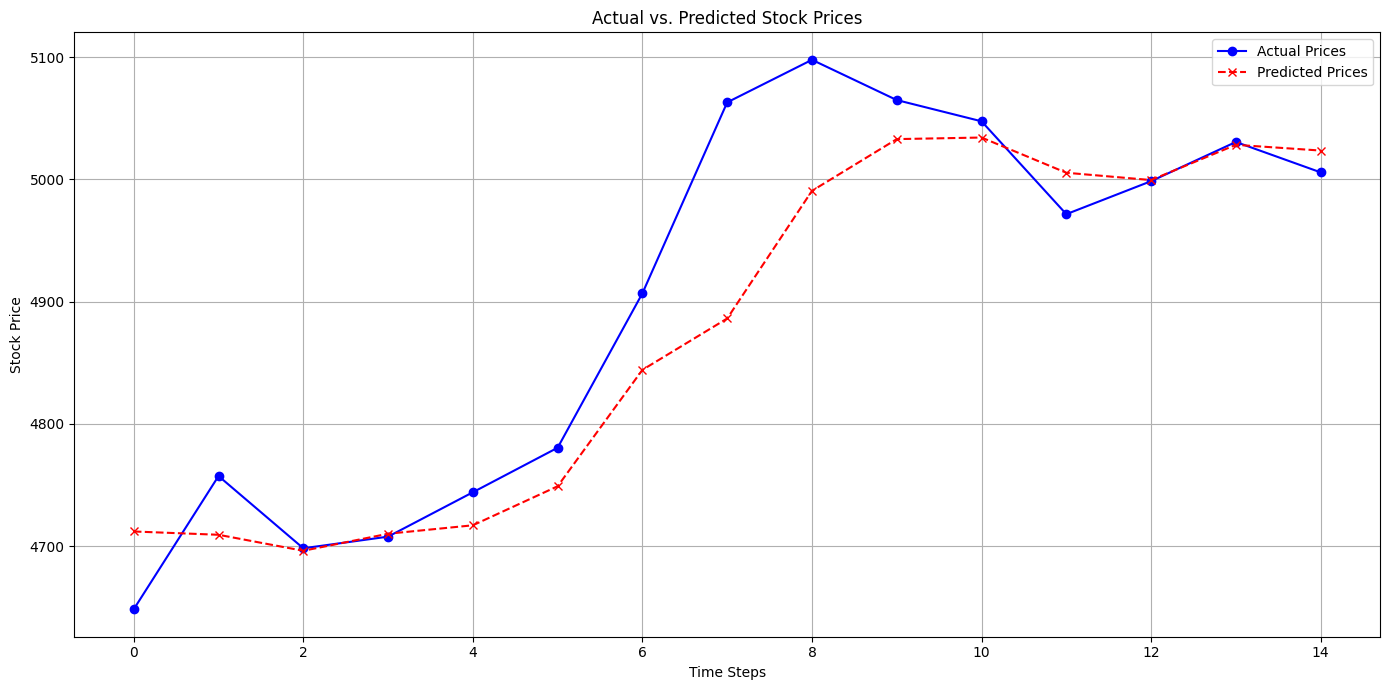

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(actuals, label='Actual Prices', color='blue', marker='o', linestyle='-')
plt.plot(preds, label='Predicted Prices', color='red', marker='x', linestyle='--')
plt.title('Actual vs. Predicted Stock Prices')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### EVALUATION

In [ ]:
if len(actuals) == 0 or len(preds) == 0:
    print("Error: 'actuals' or 'preds' lists are empty. Cannot compute metrics. Please check upstream data processing and merging steps.")
else:
    print("MAE:", mean_absolute_error(actuals, preds))
    print("RMSE:", np.sqrt(mean_squared_error(actuals, preds)))
    print("R2:", r2_score(actuals, preds))

MAE: 41.424029999998375
RMSE: 61.86964655956683
R2: 0.8394533758259977
